# Task 5 – Validation
The optimized parameter set from Task 4 is checked on the HPPC profile, which was not used for training, and on the training tests. Internal model variables are then used to see what happens inside the cell, especially the anode potential vs Li/Li⁺.

### 1. Setup
Loads the project package with the validation and internal-variable tools.

In [4]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path

PROJECT_DIR = Path(r"K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
warnings.filterwarnings("ignore")

from lfp_dfn import ProtocolConfig, CellModel, load_test, run_all
from lfp_dfn.validation import load_study, prada_baseline_config, validate_on_hppc
from lfp_dfn.internal_states import (charge_internal_states, current_internal_states, plating_summary,
                                     plot_anode_potential, plot_internal_states, plot_electrolyte_profiles)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 2. Load the optimized parameters
Reads `optimized_parameters.json` from Task 4 and rebuilds three parameter sets: the original Prada2013 values, the manual tuning (the optimizer's start point) and the optimized set.

In [5]:
DATA_DIR = PROJECT_DIR
OUT_DIR  = PROJECT_DIR / "results" / "task5"
OUT_DIR.mkdir(parents=True, exist_ok=True)
protocol = ProtocolConfig(v_cv=3.6)

PROJECT_ = Path(r"K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\optim")
study = load_study(PROJECT_ / "results" / "task4" / "optimized_parameters.json")
opt_cfg = study["optimized_cfg"]

configs = {
    "Prada2013 baseline":                prada_baseline_config(opt_cfg.T_default_C),
    "Manual tuning":                     study["start_cfg"],
    f"Optimized ({study['best_method']})": opt_cfg,
}
print("Optimized parameters:", {k: f"{v:.4g}" for k, v in study["optimized_params"].items()})
print(CellModel(opt_cfg).summary())

Optimized parameters: {'D_n': '2.501e-14', 'D_p': '7.504e-18', 'k_j0_n': '1.307', 'k_j0_p': '0.1005', 'R_contact': '0.0008395', 'beta_p': '0.0204'}
Graphite OCP: Chen2020 | soft wall: True (k=70) | y100 = 0.0191 | dU_charge = 0 mV | Q_n = 2.907 Ah, Q_p = 3.292 Ah | R_contact = 0.84 mOhm


### 3. Validation on HPPC
All three parameter sets are simulated on the HPPC profile. The table gives RMSE, MAE, max error and bias, the RMSE split into rest and pulses and into SOC ranges, and the change compared with the baseline. The plots show the residual over time and against SOC, plus a zoom on one pulse.

  simulating HPPC: Prada2013 baseline ...
    RMSE 63.2 mV | coverage 64.6 %
  simulating HPPC: Manual tuning ...
    RMSE 39.7 mV | coverage 100.0 %
  simulating HPPC: Optimized (TRF) ...
    RMSE 47.4 mV | coverage 100.0 %


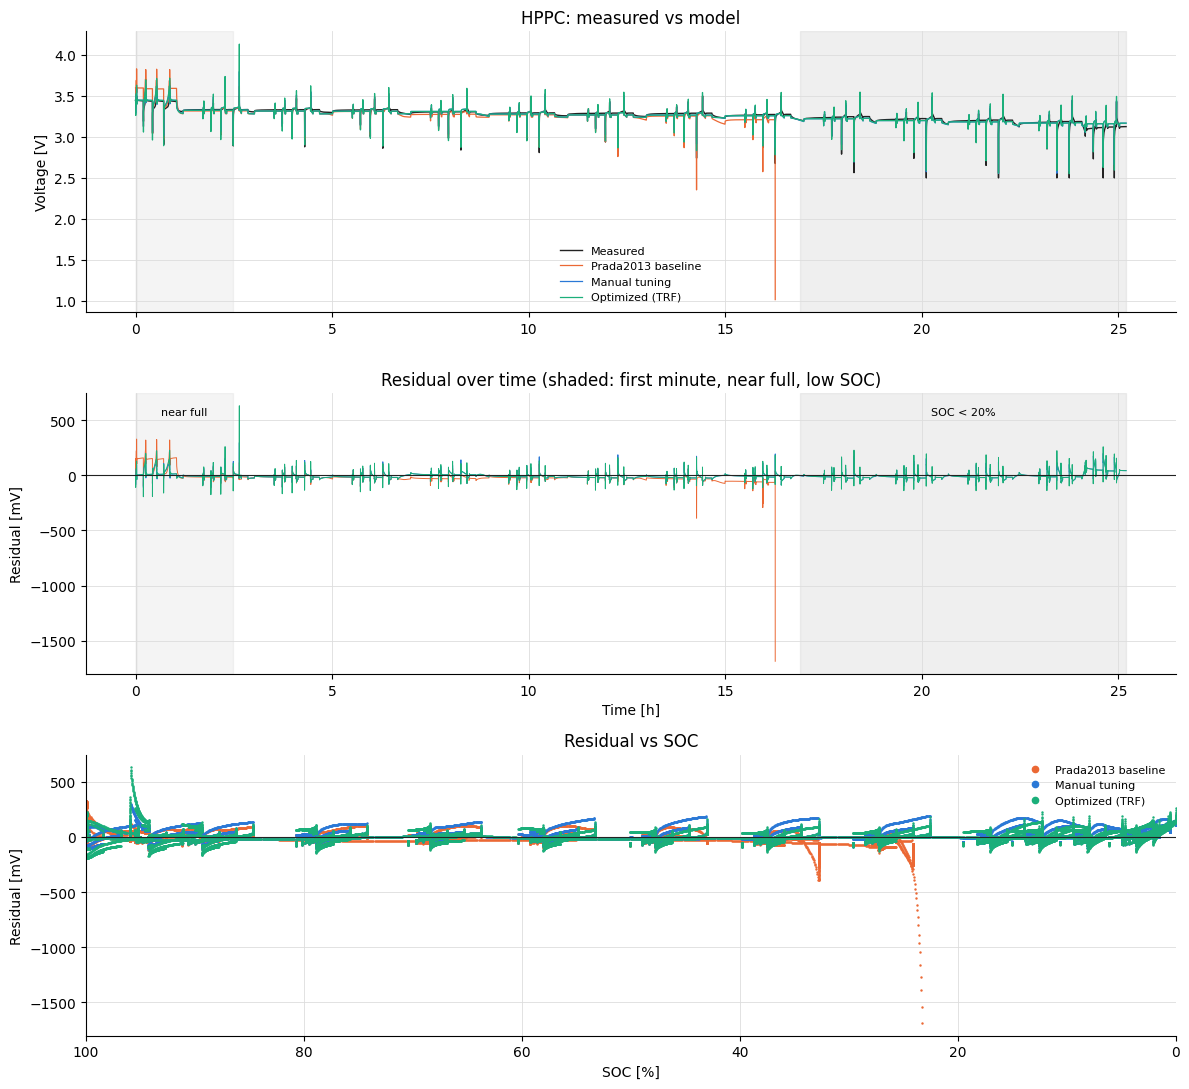

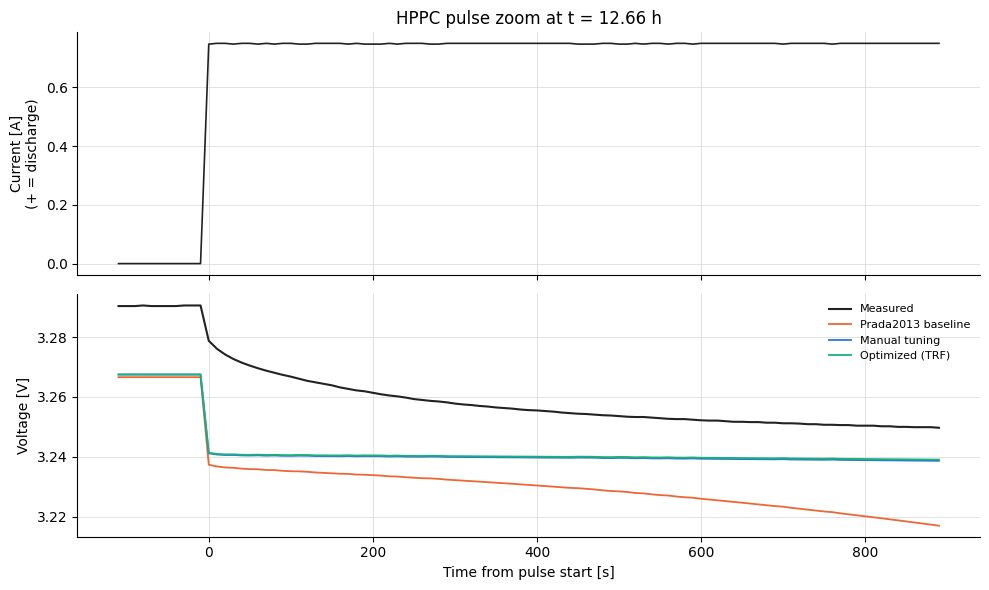

,Coverage [%],RMSE all [mV],MAE [mV],Max |error| [mV],Mean error [mV],RMSE rest [mV],RMSE discharge pulses [mV],RMSE charge pulses [mV],RMSE high SOC 100-70 % [mV],RMSE mid SOC 70-30 % [mV],RMSE low SOC 30-0 % [mV],RMSE change vs first [%]
Prada2013 baseline,64.6,63.2,41.5,1685.4,-8.2,56.5,85.8,72.3,72.3,39.3,100.8,0.0
Manual tuning,100.0,39.7,29.7,296.5,3.0,31.5,66.5,47.4,37.9,35.1,43.7,-37.1
Optimized (TRF),100.0,47.4,34.7,630.5,2.8,36.9,61.9,77.5,56.5,34.5,48.3,-25.0


In [7]:
DATA_DIR = Path(r"K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\Data_dir")
hppc = load_test(DATA_DIR, "HPPC", opt_cfg.T_default_C)
hppc_tbl, hppc_res = validate_on_hppc(configs, hppc, protocol, OUT_DIR)
display(hppc_tbl.round(1))

### 4. Training tests with the optimized set
Re-runs Charge 1C–4C and Discharge 1C with the optimized parameters, to confirm the fit and to get the final numbers for the report.

Running Charge_1C ...


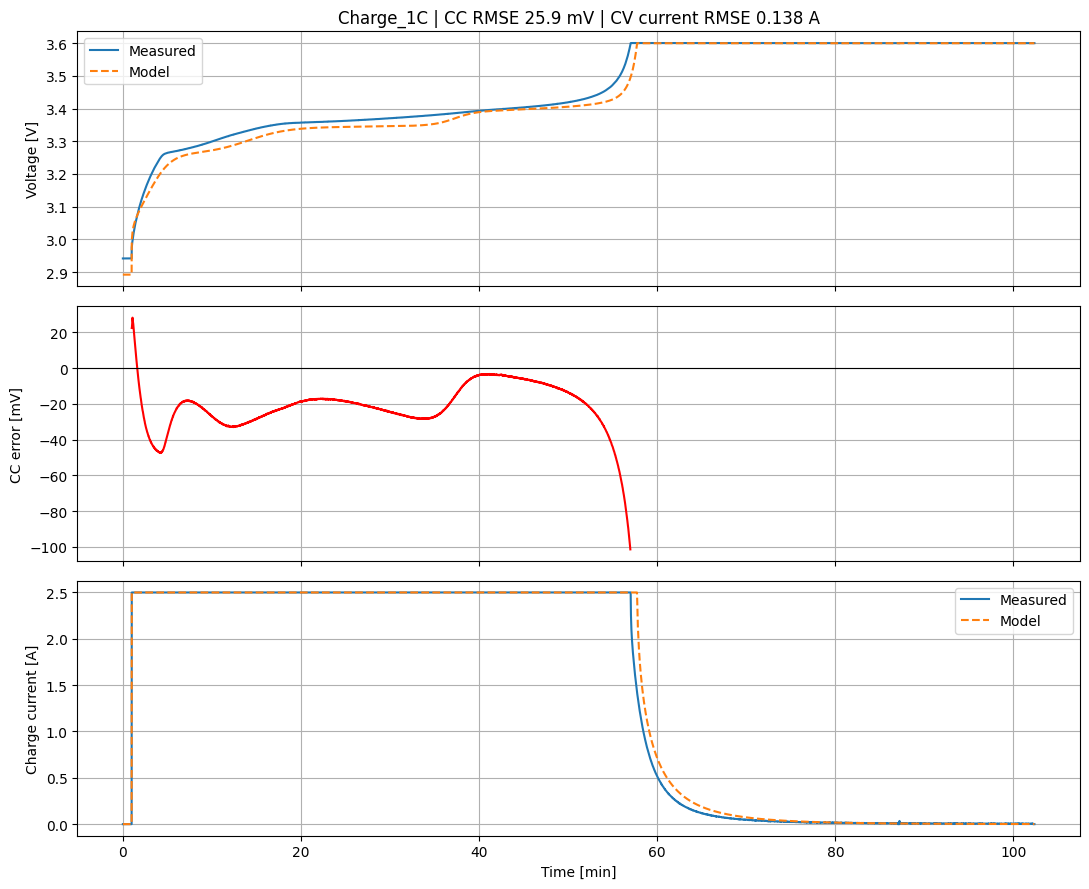

  done in 2 s
Running Charge_2C ...


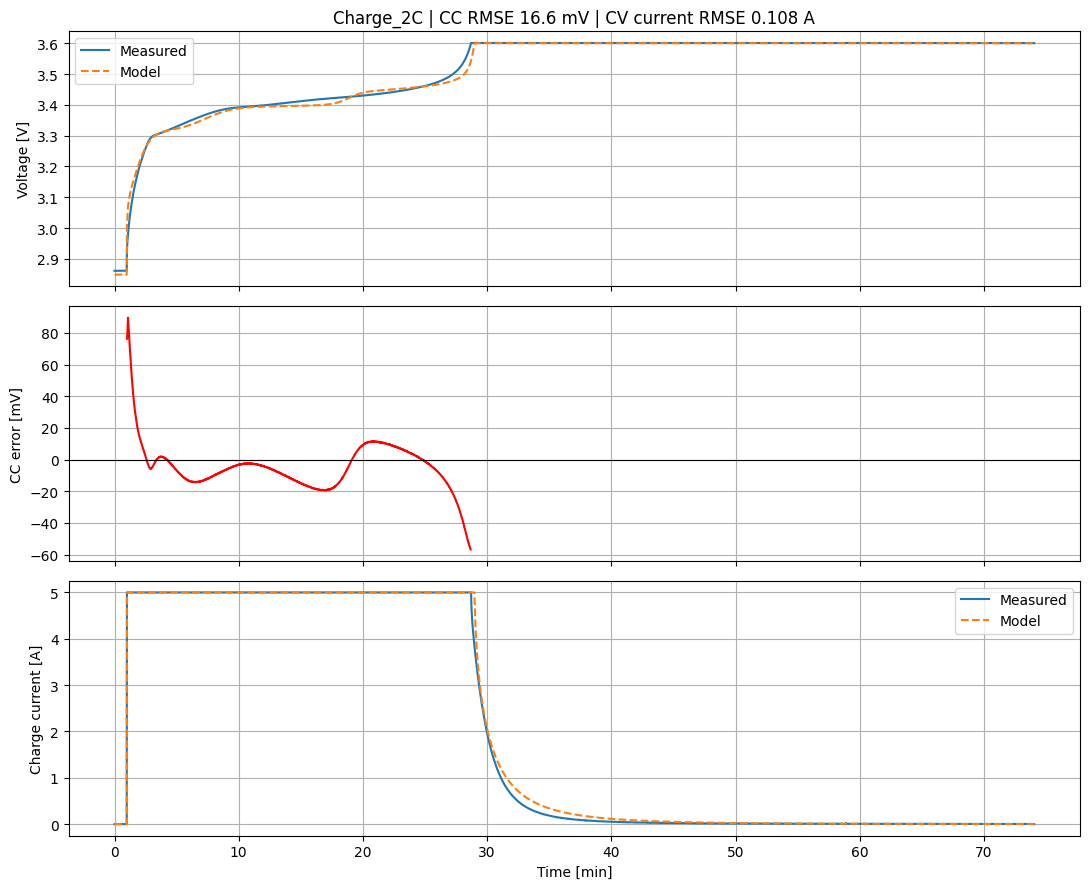

  done in 2 s
Running Charge_3C ...


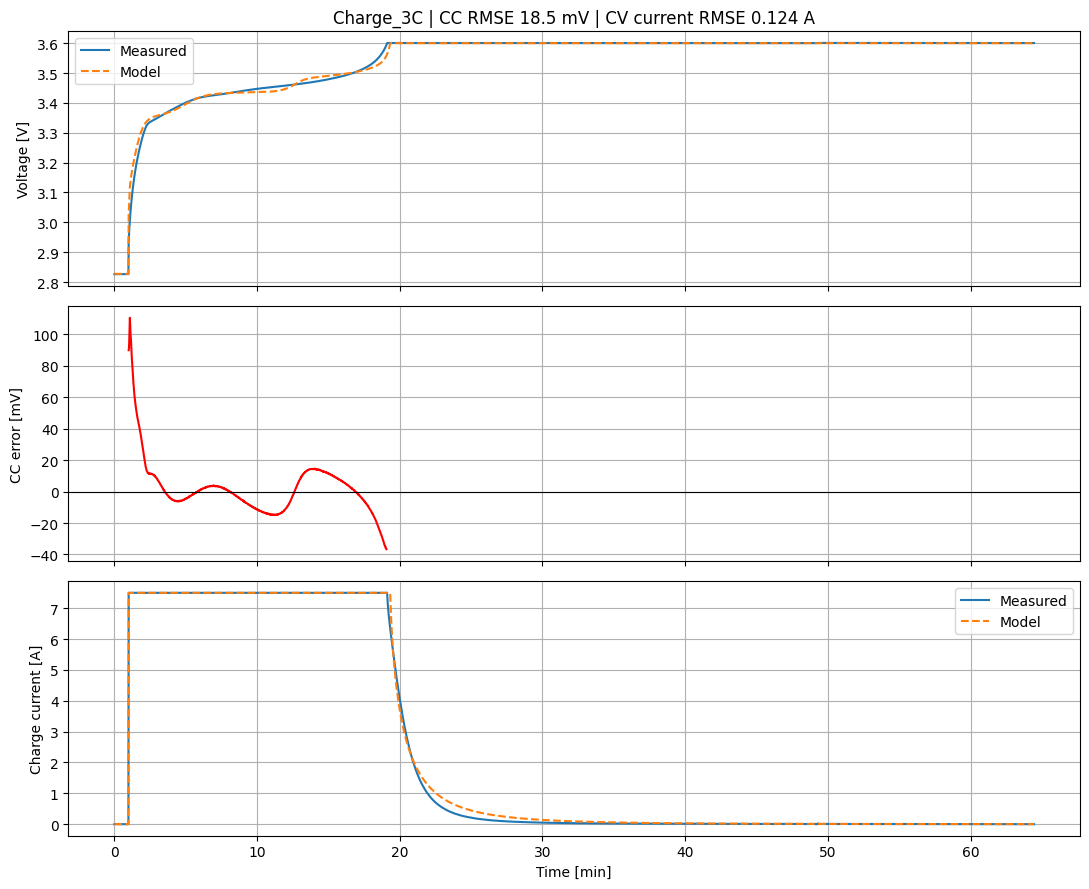

  done in 2 s
Running Charge_4C ...


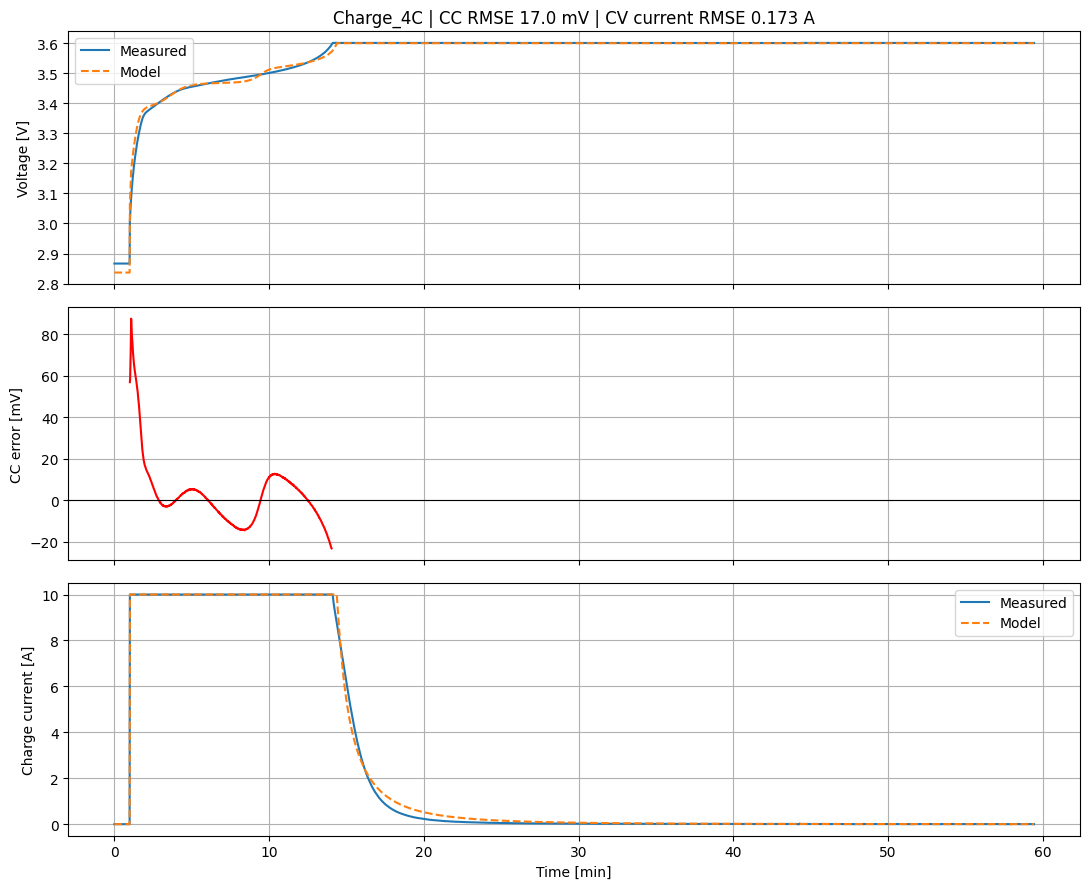

  done in 2 s
Running Discharge_1C ...


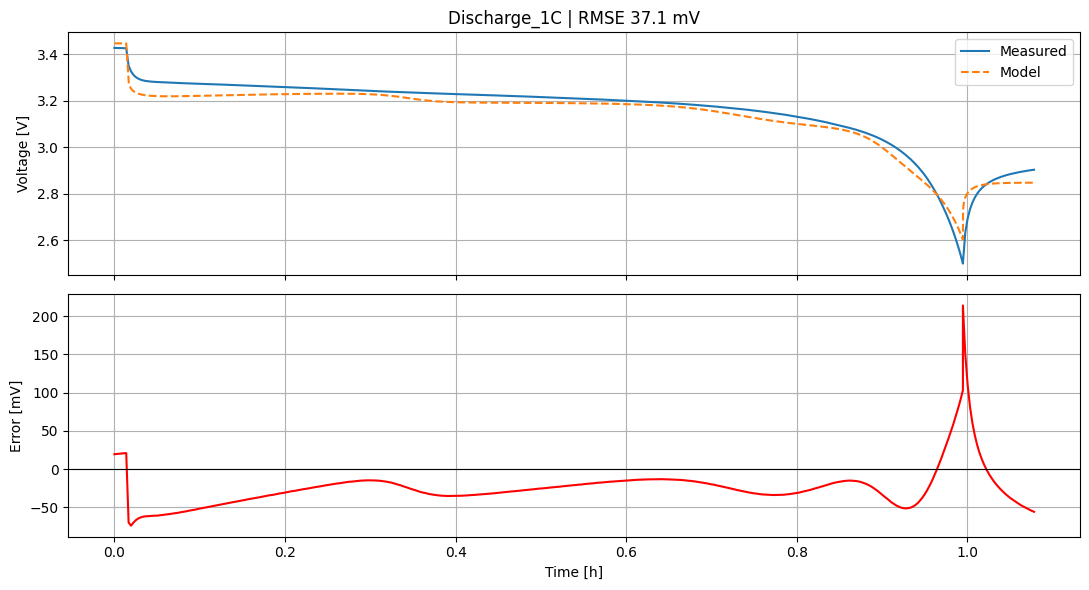

  done in 2 s

Saved to K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\results\task5\training: all_<test>.png, summary CSVs, run_config.json


,RMSE V CC [mV],Mean offset CC [mV],RMSE I CV [A],CV start model [min],CV start meas [min],Charge model [Ah],Charge meas [Ah]
Test,,,,,,,
Charge_1C,25.919,-21.892,0.138,57.725,56.996,2.459,2.423
Charge_2C,16.551,-4.821,0.108,28.970,28.684,2.483,2.447
Charge_3C,18.545,2.149,0.124,19.315,19.080,2.493,2.456
Charge_4C,16.982,3.066,0.173,14.337,14.055,2.490,2.452


,Simulated [h],Test length [h],Stop reason,RMSE V [mV],MAE V [mV],Max |error| [mV],RMSE rest [mV],RMSE current on [mV]
Test,,,,,,,,
Discharge_1C,1.078,1.078,final time,37.116,31.576,214.084,58.553,34.021


In [8]:
TRAIN_TESTS = ["Charge_1C", "Charge_2C", "Charge_3C", "Charge_4C", "Discharge_1C"]
charge_tbl, current_tbl = run_all(CellModel(opt_cfg), TRAIN_TESTS, DATA_DIR, protocol,
                                  OUT_DIR / "training", show_plots=True)
display(charge_tbl.round(3)); display(current_tbl.round(3))

### 5. Anode potential and internal variables during charging
The four charge tests are simulated again with the optimized set, keeping the internal variables. The anode potential at the separator side is the main one: if it drops below 0 V vs Li/Li⁺, lithium plating becomes possible. The 4C charge is the worst case, so it is shown in full detail, together with the electrolyte concentration across the cell.

  Charge_1C ...
  Charge_2C ...
  Charge_3C ...
  Charge_4C ...


,Min anode potential (separator side) [mV],Time of minimum [min],Time below 0 V [s],Min anode potential (average) [mV],Min graphite surface stoichiometry,Max graphite surface stoichiometry,Min LFP surface stoichiometry,Max |eta_n| [mV],Max |eta_p| [mV]
Charge_1C,6.508,57.732,0.000,7.575,0.075,0.921,0.008,88.441,33.337
Charge_2C,-29.492,28.976,578.587,-27.296,0.067,0.921,0.008,125.281,50.179
Charge_3C,-52.673,19.326,484.579,-49.259,0.063,0.921,0.008,146.997,59.627
Charge_4C,-69.852,14.373,642.437,-65.108,0.065,0.921,0.008,161.090,63.906


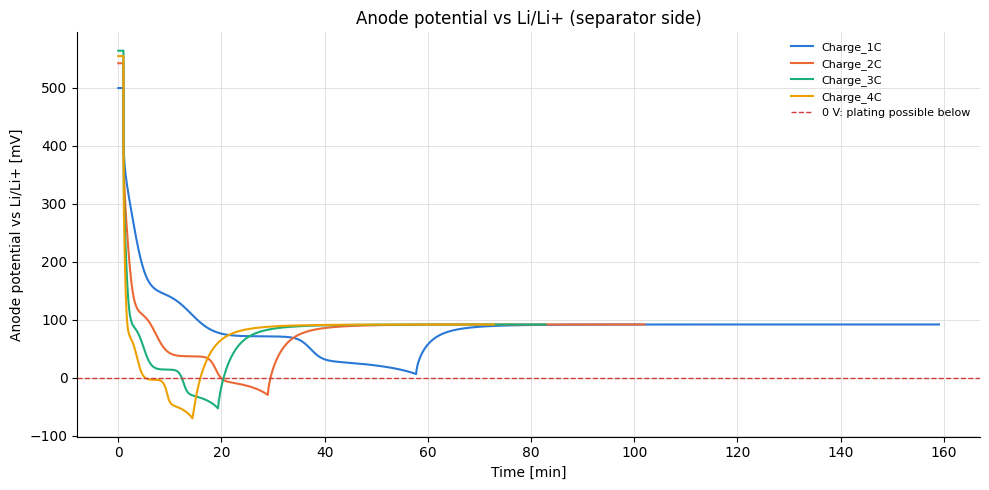

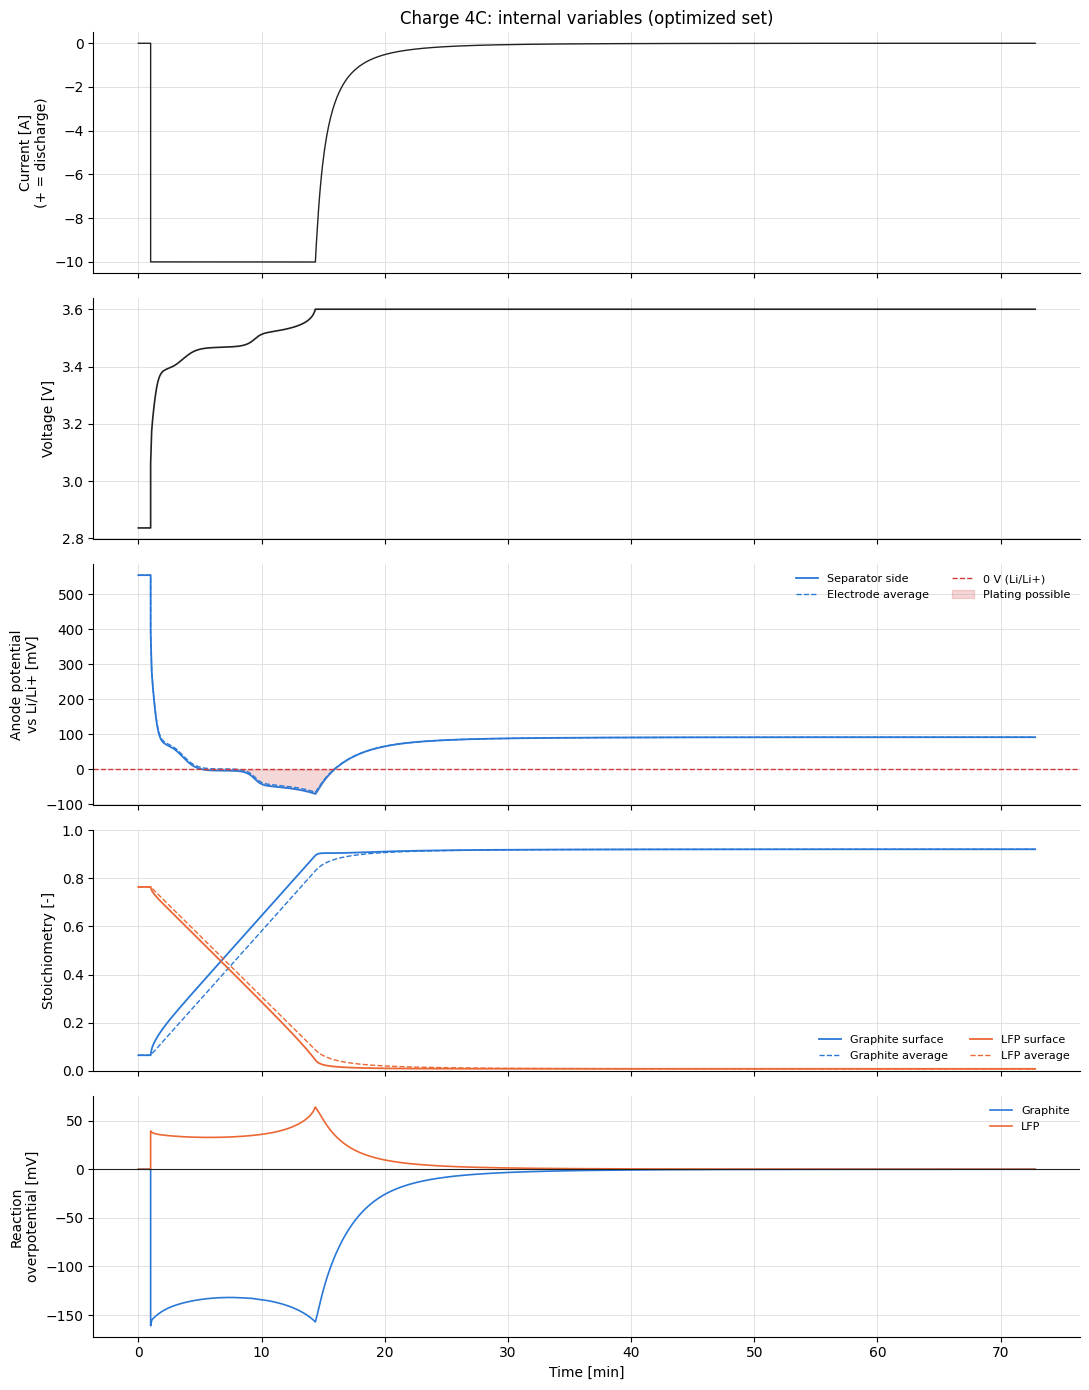

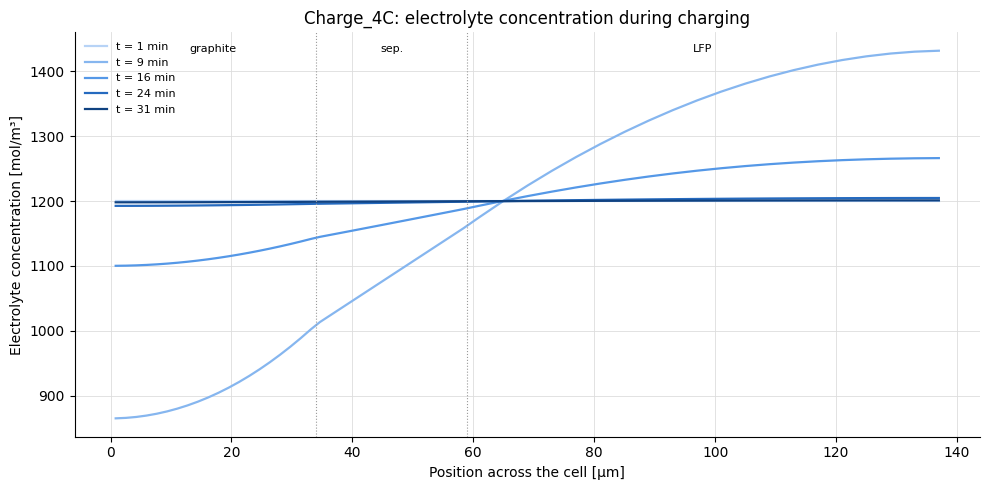

In [9]:
cell_opt = CellModel(opt_cfg)
charge_states = {}
for name in ["Charge_1C", "Charge_2C", "Charge_3C", "Charge_4C"]:
    print(f"  {name} ...", flush=True)
    charge_states[name] = charge_internal_states(cell_opt, load_test(DATA_DIR, name, opt_cfg.T_default_C), protocol)

display(plating_summary(charge_states).round(3))
plot_anode_potential(charge_states, OUT_DIR / "anode_potential_charge.png")
plot_internal_states(charge_states["Charge_4C"], "Charge 4C: internal variables (optimized set)",
                     OUT_DIR / "internal_states_charge_4C.png")
plot_electrolyte_profiles(charge_states["Charge_4C"], save_path=OUT_DIR / "electrolyte_charge_4C.png")

### 6. Internal variables during HPPC
The same variables for the full HPPC profile. This shows how the anode potential and the particle surface stoichiometries behave during pulses at different SOC levels.

,Min anode potential (separator side) [mV],Time of minimum [min],Time below 0 V [s],Min anode potential (average) [mV],Min graphite surface stoichiometry,Max graphite surface stoichiometry,Min LFP surface stoichiometry,Max |eta_n| [mV],Max |eta_p| [mV]
HPPC,-90.022,158.223,193.142,-87.022,0.085,0.915,0.001,219.13,156.41


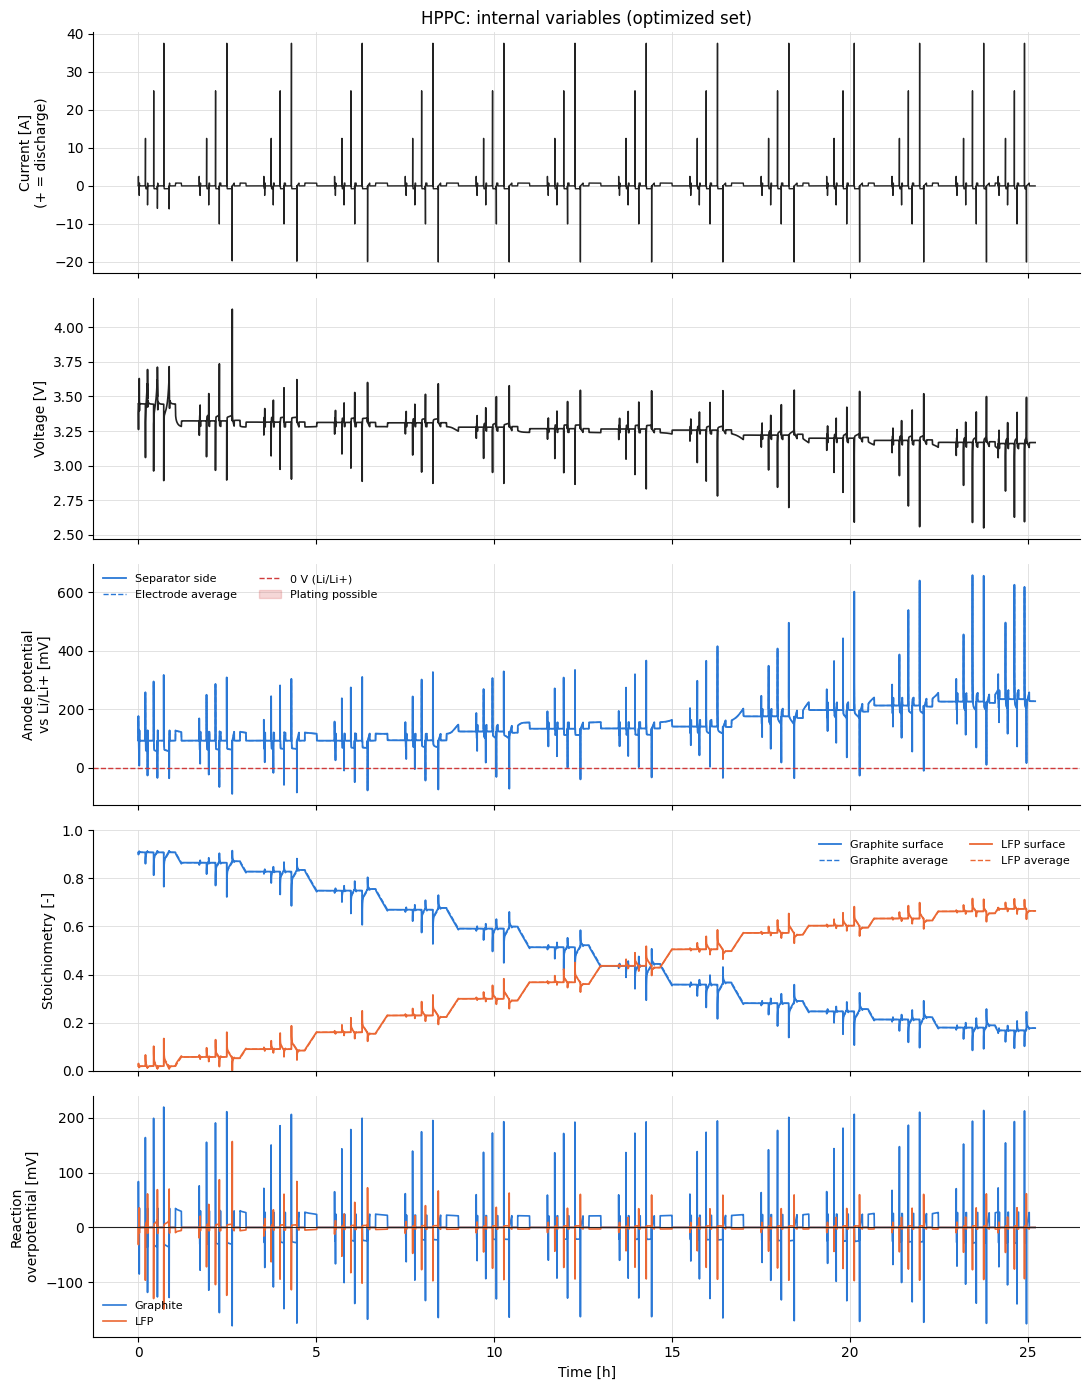

In [10]:
hppc_states = current_internal_states(cell_opt, hppc)
display(plating_summary({"HPPC": hppc_states}).round(3))
plot_internal_states(hppc_states, "HPPC: internal variables (optimized set)",
                     OUT_DIR / "internal_states_hppc.png", time_unit="h")

### 7. Save results
Saves the validation metrics and the internal-variable summary to `results/task5`.

In [11]:
summary = plating_summary({**charge_states, "HPPC": hppc_states})
summary.to_csv(OUT_DIR / "internal_states_summary.csv")
print(f"Saved to {OUT_DIR}")

Saved to K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\results\task5


### Why these error metrics
RMSE is the main metric. It is in mV like the voltage, it weights large errors more (and the big deviations during pulses and at low SOC are what matter for a BMS), and it matches the least-squares objective used in Task 4, so training and validation use the same yardstick. MAE shows the typical error, the max error the worst case, and the mean error a systematic offset. Splitting the RMSE into rest and pulses tells whether the remaining error comes from the OCV or from the dynamics, and the SOC ranges show where the model is weakest. MAPE and R² are not used because the high voltage level makes them look good even for a poor fit.

### What the internal variables tell us
- **Anode potential vs Li/Li⁺:** stays above 0 V → no plating risk in these tests. If it dips below 0 V (most likely at the end of the 4C CC phase), plating is possible and the minimum value shows how big the risk is.
- **Surface vs average stoichiometry:** a large gap means diffusion limits. On graphite this shows up at high C-rates; on LFP near full charge, which is what β_p describes.
- **Reaction overpotentials:** show how much of the voltage loss is kinetics.
- **Electrolyte concentration:** a strong gradient at 4C means salt depletion, which adds to the voltage loss at high current.